In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
# ====================================================================================
# REPRODUÇÃO DA ANÁLISE EXPLORATÓRIA REALIZADA PELOS AUTORES
# ====================================================================================


# importação do dataset original e filtragem da faixa temporal analisada pelos autores
df = pd.read_csv("events.csv")
df["event_time"] = df["event_time"].str.removesuffix("UTC")
df["event_time"] = pd.to_datetime(df["event_time"])
df["year"] = df["event_time"].dt.year
df["month"] = df["event_time"].dt.month
df["day"] = df["event_time"].dt.day
df["hour"] = df["event_time"].dt.hour
teste = df[(df["month"] == 2) & (df["day"] >=1) & (df["day"]<=14)].copy()
teste

# teste : dados filtrados por data, sem alteração
# df : dados originais, ja com a adequação das variáveis datetime

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,year,month,day,hour
718150,2021-02-01 00:00:24,view,3829355,2144415922528452715,electronics.telephone,NaN,32.22,1515915625599249719,tLDz4Sqhex,2021,2,1,0
718151,2021-02-01 00:00:26,view,1079370,2144415922528452715,electronics.telephone,NaN,35.71,1515915625599244362,BjS7huYFYy,2021,2,1,0
718152,2021-02-01 00:01:21,view,4100254,2144415922427789416,computers.components.videocards,asus,187.29,1515915625599171655,mJndx3tNRh,2021,2,1,0
718153,2021-02-01 00:01:21,view,1843522,2144415921169498184,NaN,NaN,15.08,1515915625599248306,JppGOnkO1z,2021,2,1,0
718154,2021-02-01 00:02:01,view,4079414,2144415927049912542,electronics.video.tv,starwind,87.46,1515915625599247497,GprKXGbhaV,2021,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
805747,2021-02-14 23:59:00,view,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625605588306,XbXUhGj9Yn,2021,2,14,23
805748,2021-02-14 23:59:38,view,4183864,2144415922427789416,computers.components.videocards,palit,587.60,1515915625605588405,NNc7dn3q2p,2021,2,14,23
805749,2021-02-14 23:59:39,view,3698823,2144415922050302046,NaN,palmexx,14.10,1515915625605588204,WCopm21l2B,2021,2,14,23
805750,2021-02-14 23:59:47,cart,4183864,2144415922427789416,computers.components.videocards,palit,587.60,1515915625605588405,NNc7dn3q2p,2021,2,14,23


<Axes: xlabel='hour', ylabel='events'>

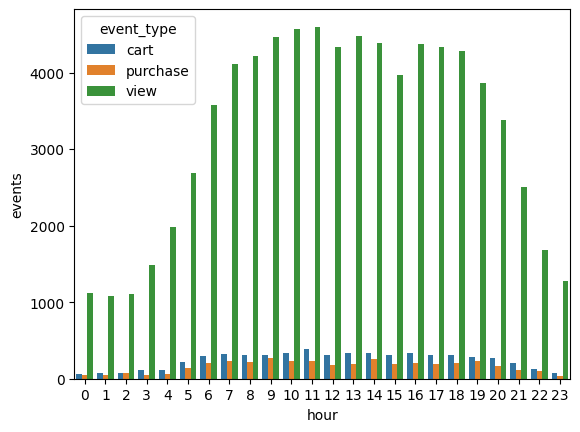

In [10]:
# plot de barras dos eventos, segmentados por hora do dia
# nota-se pelo plot que os eventos de view tem mais de 4500 observações em alguma horas do dia
# enquanto a anllise dos autores apresenta < 2000 observações
teste_graf_1 = teste.groupby(["hour",  "event_type"]).agg(events = ("event_type","count"))
teste_graf_1.reset_index(inplace = True)
sns.barplot(data = teste_graf_1, x = "hour", y = "events", hue = "event_type")

<Axes: xlabel='hour', ylabel='events'>

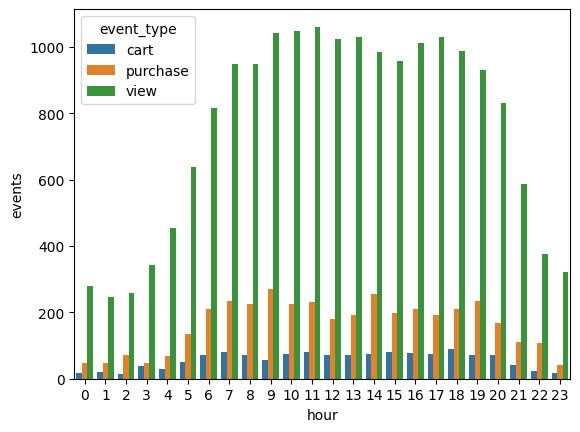

In [9]:
# Os autores não deixam em evidência qual tratamento de dados foi aplicado para obter o gráfico de eventos x hora
# Porvavelmente os autores realizaram a análise exploratória com os dados ja balanceados na proporção de "purchase": "non_purchase" em 4:1
# 1ª estratégia de correção: agrupar por usuário e por
balanço = teste[["hour", "event_type"]]
purchase = teste[teste["event_type"] == "purchase"].copy()
non_purchase = teste[teste["event_type"] != "purchase"].sample(len(purchase)*5)
final = pd.concat([purchase,non_purchase])
teste_graf_2 = final.groupby(["hour",  "event_type"]).agg(events = ("event_type","count"))
teste_graf_2.reset_index(inplace = True)
sns.barplot(data = teste_graf_2, x = "hour", y = "events", hue = "event_type")

In [ ]:
# a estratégia de balancear a quantidade de eventos antes da segmentação em eventos entregou uma quantidade muito menor de views
# De toda forma, o peimeiro gráfico de barras é o mais correto, estatísticamente, sendo que ele considera a quantidade total de eventos observados no período de tempo analisado
# Considera os dados em sua totalidade e todos os eventos

<Axes: xlabel='price', ylabel='Density'>

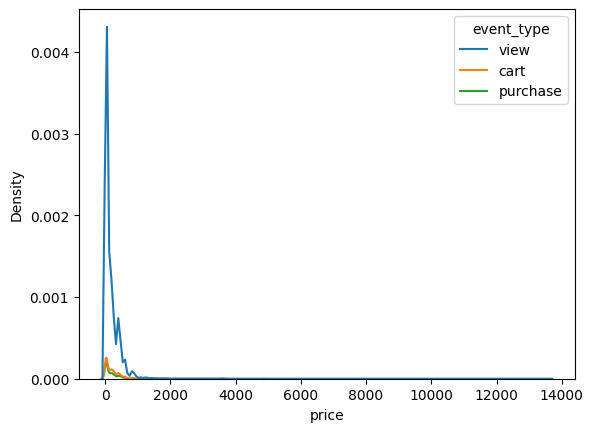

In [11]:
# gráfico de densidade por valor
sns.kdeplot(data = teste, x = "price", hue = "event_type")

<Axes: xlabel='price', ylabel='Density'>

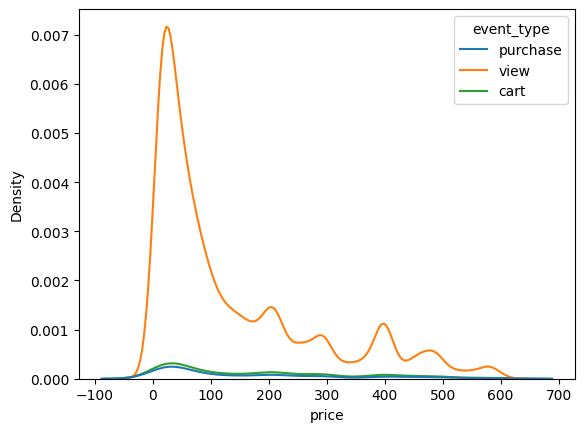

In [12]:
# o gráfico de densidade por valor obtido no cmando acima ficou muito diferente daquele exposto pelos autores
# ao que parece, os autores excluíram produtos com valor maior que 600
teste.sort_values(by = "price", ascending = False, inplace = True)
teste = teste[teste["price"] <600].copy()
sns.kdeplot(data = teste, x = "price", hue = "event_type")

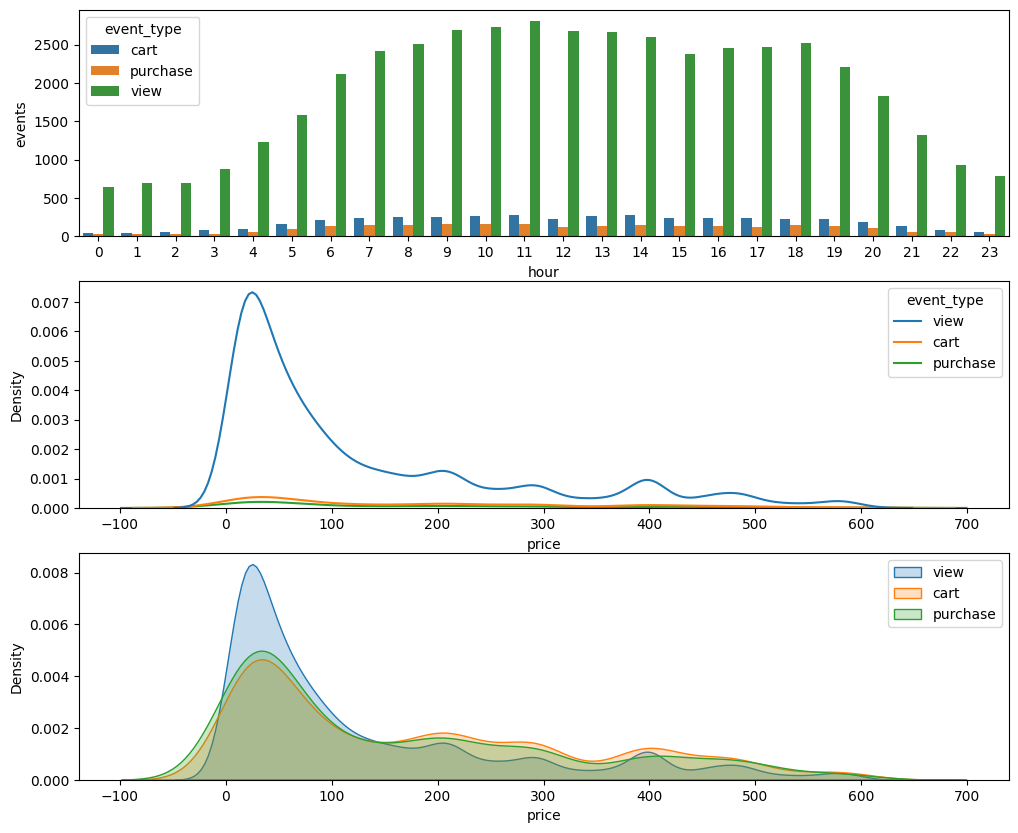

In [13]:
# mesmo excluíndo produtos acima de 600 o gráfico ainda ficou muito diferente, uma nova abordagem de segmentação deve ser testada para obter um gráfico semelhante ao dos autores

# agrupei por usuário, depois por tipo de evento, tentando aproximar meu resultado do resultado obtido pelos autores
# coloquei todos os valores de hora em formato de lista, para cada usuário e tipo de evento
# a ideia foi eliminar valores repetidos
# SÃO MÉTRICAS DIFERENTES - OS AUTORES NÃO DEIXAM CLARO QUAL A MPETRICA USADA
hour = teste.groupby(["user_id", "event_type"], as_index = False)["hour"].agg("unique")
hour = hour.explode("hour")
hour = hour.groupby(["hour", "event_type"]).agg(events = ("event_type", "count"))

# para o gráfico de preço, tentei usar o sns.kdeplot com "hue" para segmentação por tipo de evento, mas não funcionou
# isso por que ele coloca todas as classes na mesma densidade de probabilidade
# então fiz 3 sets diferentes, um para cada tipo de evento, e plotei os 3 no mesmo gráfico
price = teste.groupby(["user_id","event_type"], as_index = False)["price"].agg("unique")
price = price.explode("price")
price_view = price[price["event_type"] == "view"]
price_cart = price[price["event_type"] == "cart"]
price_purchase = price[price["event_type"] == "purchase"]

figura, axis = plt.subplots(3,1, figsize = (12,10))
sns.barplot(data = hour, x = "hour", y = "events", hue = "event_type", ax = axis[0])
sns.kdeplot(data = price, x = "price", hue = "event_type", ax = axis[1])
sns.kdeplot(data = price_view, x = "price", ax = axis[2], label = "view", fill= True)
sns.kdeplot(data = price_cart, x = "price", ax = axis[2], label = "cart", fill = True)
sns.kdeplot(data = price_purchase, x = "price", ax = axis[2], label = "purchase", fill = True)
axis[2].legend()



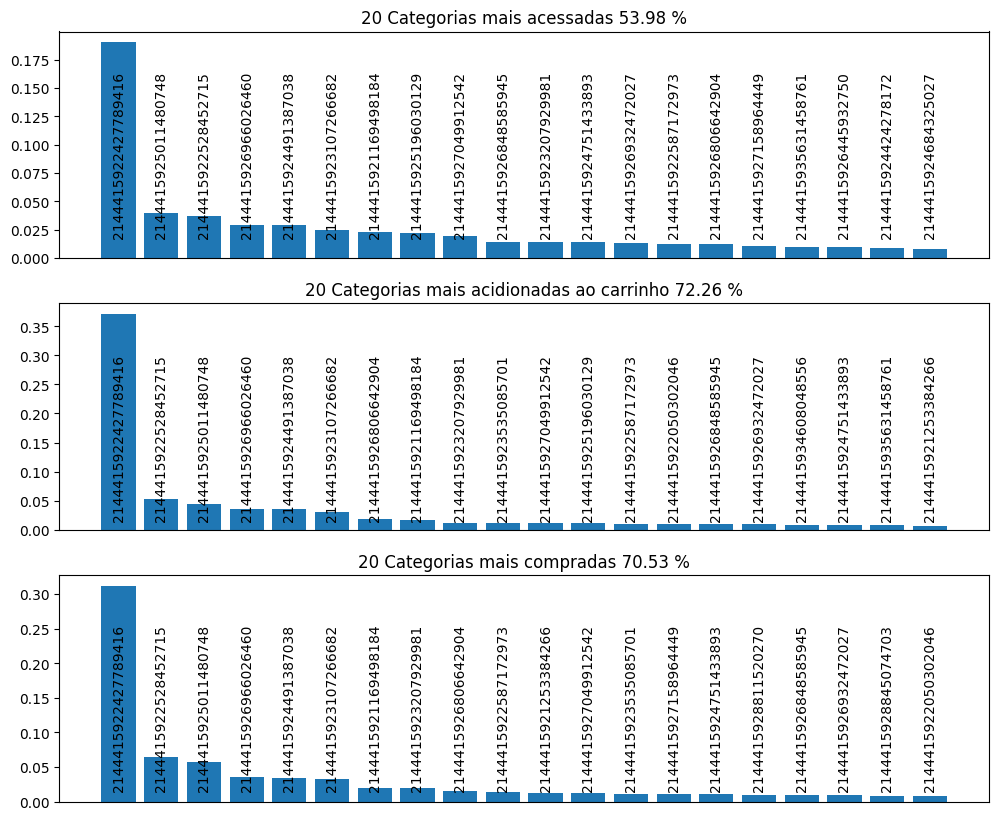

In [14]:
# algo que desperta a cureosidade, existe alguma categoria dominante em views, ou em vendas ?
# existem os "poucos que agregam muito" em categorias ?
# visando elucidar essa questão, eu fiz um diagrama de Paretto utilizando as categorias

produtos = pd.crosstab(teste["category_id"], teste["event_type"])
produtos.reset_index(inplace = True)
mais_acessados = produtos[["category_id", "view"]].sort_values(by = "view", ascending = False)
mais_acessados["view %"] = mais_acessados["view"] / mais_acessados["view"].sum()
mais_acessados["acc"] = mais_acessados["view %"].cumsum()
mais_carrinhos = produtos[["category_id", "cart"]].sort_values(by = "cart", ascending = False)
mais_carrinhos["cart %"] = mais_carrinhos["cart"] / mais_carrinhos["cart"].sum()
mais_carrinhos["acc"] = mais_carrinhos["cart %"].cumsum()
mais_comprados = produtos[["category_id", "purchase"]].sort_values(by = "purchase", ascending = False)
mais_comprados["purchase %"] = mais_comprados["purchase"] / mais_comprados["purchase"].sum()
mais_comprados["acc"] = mais_comprados["purchase %"].cumsum()

figura, axis = plt.subplots(3,1, figsize = (12,10))

acessos = mais_acessados.iloc[0:20]
axis[0].bar(range(0,20), acessos["view %"])
axis[0].set_xticks([])
for idx, i in enumerate(acessos["category_id"]):
  axis[0].text(idx, 0.02, s = i, rotation = "vertical", ha = "center")
axis[0].set_title(f"20 Categorias mais acessadas {round(acessos['view %'].sum()*100,2)} %")

carts = mais_carrinhos.iloc[0:20]
axis[1].bar(range(0,20), carts["cart %"])
axis[1].set_xticks([])
for idx, i in enumerate(carts["category_id"]):
  axis[1].text(idx, 0.02, s = i, rotation = "vertical", ha = "center")
axis[1].set_title(f"20 Categorias mais acidionadas ao carrinho {round(carts['cart %'].sum()*100,2)} %")

purchase = mais_comprados.iloc[0:20]
axis[2].bar(range(0,20), purchase["purchase %"])
axis[2].set_xticks([])
for idx, i in enumerate(purchase["category_id"]):
  axis[2].text(idx, 0.02, s = i, rotation = "vertical", ha = "center")
axis[2].set_title(f"20 Categorias mais compradas {round(purchase['purchase %'].sum()*100,2)} %")

plt.show()

In [15]:
# tratamento dos dados com o set inteiro e comparação dos resultados da análise exploratória
for i in df.columns:
  print(f"a variável '{i}' tem {df[i].isna().astype(float).sum()} valores inválidos")


a variável 'event_time' tem 0.0 valores inválidos
a variável 'event_type' tem 0.0 valores inválidos
a variável 'product_id' tem 0.0 valores inválidos
a variável 'category_id' tem 0.0 valores inválidos
a variável 'category_code' tem 236219.0 valores inválidos
a variável 'brand' tem 212364.0 valores inválidos
a variável 'price' tem 0.0 valores inválidos
a variável 'user_id' tem 0.0 valores inválidos
a variável 'user_session' tem 165.0 valores inválidos
a variável 'year' tem 0.0 valores inválidos
a variável 'month' tem 0.0 valores inválidos
a variável 'day' tem 0.0 valores inválidos
a variável 'hour' tem 0.0 valores inválidos


In [16]:
# preparação do dataset contendo todas as observações
df.drop(["category_code", "brand"], axis = 1, inplace = True)
dropar = df[df["user_session"].isna() == True].index
df.drop(dropar, axis = 0, inplace = True)

hora_full = df.groupby(["user_id", "event_type"], as_index = False)["hour"].agg("unique")
hora_full = hora_full.explode("hour")
hora_full = hora_full.groupby(["hour", "event_type"]).agg(events= ("event_type", "count"))

price_full = df[df["price"] <= 600]

Text(0.5, 1.0, 'Data from 2020-09-24 to 2021-02-28')

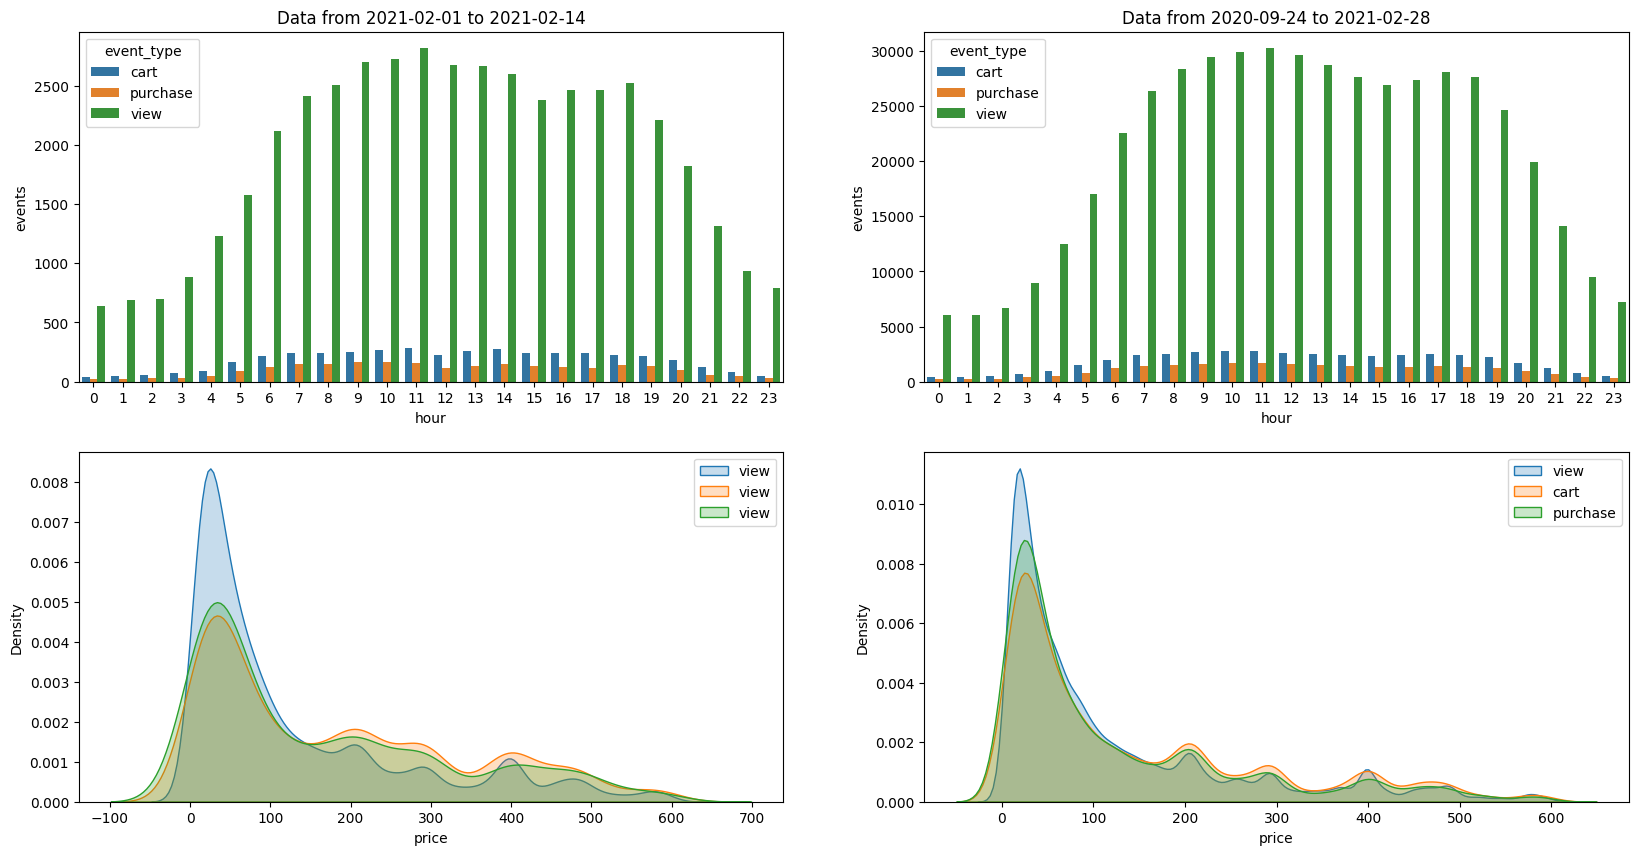

In [17]:
# plot da distribuição de eventos por hora do dia e da densidade de probabilidade de evento por valor
# para os dados filtrados (01/02/2021 a 14/02/2021) a esqueda e para os dados completos (24/09/2020 a 28/02/2021) a direita
# nota-se que não ha diferença significante nos padrões analisados
figura, axis = plt.subplots(2,2, figsize = (20,10))

sns.barplot(ax = axis[0,0], data = hour, x = "hour", y = "events", hue = "event_type")
sns.barplot(ax = axis[0,1], data = hora_full, x = "hour", y = "events", hue = "event_type")

sns.kdeplot(ax = axis[1,0], data = price_view, x = "price", fill = True, label = "view")
sns.kdeplot(ax = axis[1,0], data = price_cart, x = "price", fill = True, label = "view")
sns.kdeplot(ax = axis[1,0], data = price_purchase, x = "price", fill = True, label = "view")
axis[1,0].legend()


view_full = df[(df["event_type"] == "view") & (df["price"] <= 600)]
sns.kdeplot(ax = axis[1,1], data = view_full, x = "price", label = "view", fill = True)
cart_full = df[(df["event_type"] == "cart") & (df["price"] <= 600)]
sns.kdeplot(ax = axis[1,1], data = cart_full, x = "price", label = "cart", fill = True)
purchase_full = df[(df["event_type"] == "purchase") & (df["price"] <= 600)]
sns.kdeplot(ax = axis[1,1], data = purchase_full, x = "price", label = "purchase", fill = True)
axis[1,1].legend()

axis[0,0].set_title("Data from 2021-02-01 to 2021-02-14")
axis[0,1].set_title(f"Data from {df['event_time'].dt.date.min()} to {df['event_time'].dt.date.max()}")



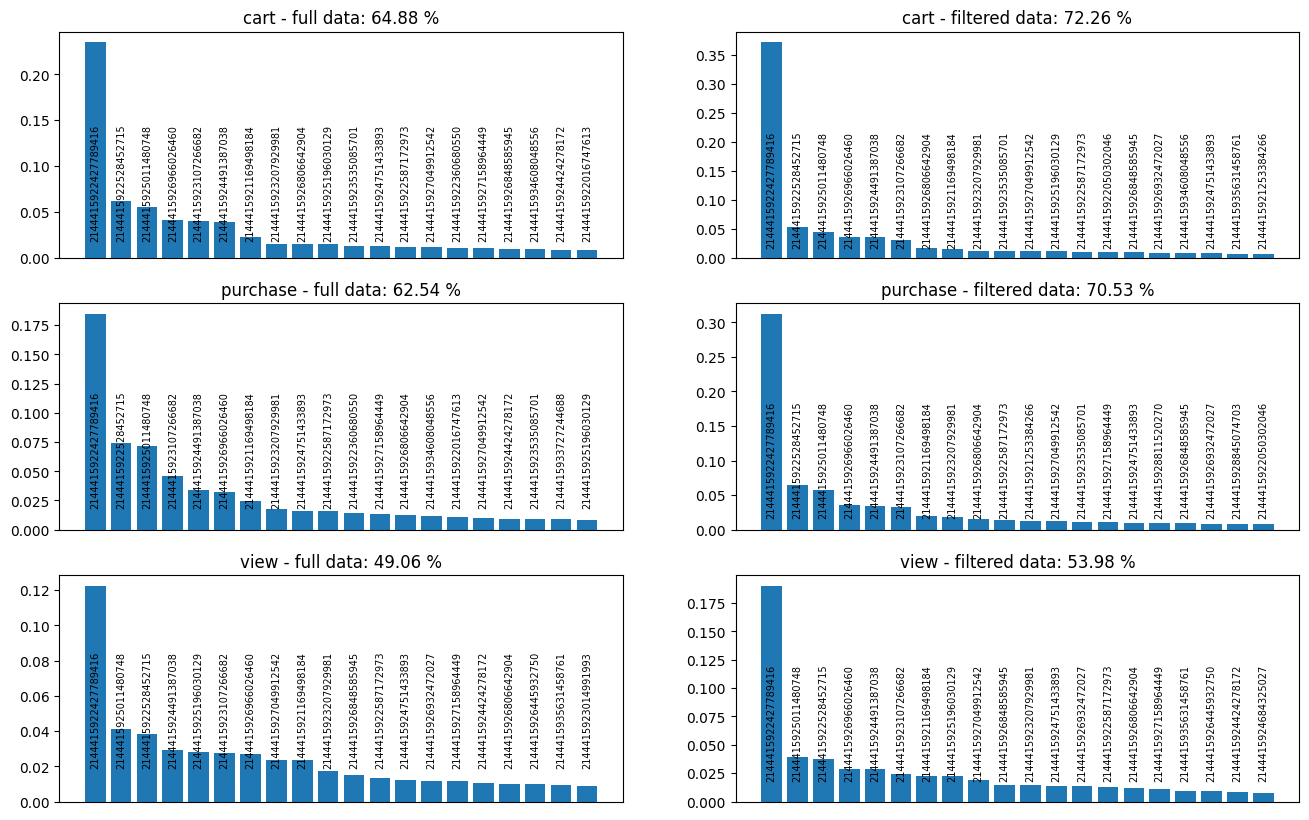

In [41]:
# obtenção dos diagramas de paretto para os dados em sua totalidade e comparação com os diagramas realizados na faixa temporal usada pelos autores

categories_full = pd.crosstab(df["category_id"], df["event_type"])
categories_full.reset_index(inplace = True)


categories = pd.crosstab(teste["category_id"], teste["event_type"])
categories.reset_index(inplace = True)

lista = ["cart", "purchase", "view"]

figura, axis = plt.subplots(3,2, figsize = (16,10))
for i in range(0,3):

  temp = categories_full[["category_id",lista[i]]].copy()
  temp[f"{lista[i]} %"] = temp[lista[i]]/ temp[lista[i]].sum()
  temp["acc"] = temp[f"{lista[i]} %"].cumsum()
  temp.sort_values(by = f"{lista[i]} %", inplace = True, ascending= False)
  graf = temp.iloc[0:20]

  axis[i,0].bar(range(0,20), graf[f"{lista[i]} %"])
  for idx, t in enumerate(graf["category_id"]):
    axis[i,0].text(idx, 0.02, s = t, rotation = "vertical", ha = "center", fontsize = 7)
  axis[i,0].set_xticks([])
  axis[i,0].set_title(f"{lista[i]} - full data: {round(graf.iloc[:,2].sum()*100,2)} %")


  temp = categories[["category_id",lista[i]]].copy()
  temp[f"{lista[i]} %"] = temp[lista[i]]/ temp[lista[i]].sum()
  temp["acc"] = temp[f"{lista[i]} %"].cumsum()
  temp.sort_values(by = f"{lista[i]} %", inplace = True, ascending= False)
  graf = temp.iloc[0:20]

  axis[i,1].bar(range(0,20), graf[f"{lista[i]} %"])
  for idx, t in enumerate(graf["category_id"]):
    axis[i,1].text(idx, 0.02, s = t, rotation = "vertical", ha = "center", fontsize = 7)
  axis[i,1].set_xticks([])
  axis[i,1].set_title(f"{lista[i]} - filtered data: {round(graf.iloc[:,2].sum()*100,2)} %")
